Hypothesis testing- example

In [ ]:
import numpy as np
from scipy import stats

# Example data: marks of 15 students in math
marks = np.array([88, 78, 82, 90, 81, 75, 87, 90, 78, 73, 72, 80, 83, 85, 75])

# Hypothesized population mean
mu = 80

# Perform one-sample t-test
t_stat, p_value = stats.ttest_1samp(marks, mu)

print(f"Sample Mean: {np.mean(marks):.2f}")
print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_value:.3f}")

# level of significance we are choosing as 0.05, we are taking 5% risk of stating average being 80 when it is not.
alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis: The average is significantly different from 80.")
else:
    print("Fail to reject the null hypothesis: No significant difference from 80.")

Sample Mean: 81.13
T-statistic: 0.732
P-value: 0.476
Fail to reject the null hypothesis: No significant difference from 80.


A/B Testing - example

In [ ]:
import numpy as np
import statsmodels.api as sm

# Example data
# Group A (control)
visitors_A = 1000
conversions_A = 120   # 12% conversion

# Group B (variation)
visitors_B = 980
conversions_B = 150   # 15.3% conversion

# Conversion rates
rate_A = conversions_A / visitors_A
rate_B = conversions_B / visitors_B

print(f"Conversion Rate A: {rate_A:.3f}")
print(f"Conversion Rate B: {rate_B:.3f}")

# Prepare data for z-test
count = np.array([conversions_A, conversions_B])     # successes
nobs = np.array([visitors_A, visitors_B])            # trials

# Perform two-proportion z-test
z_stat, p_value = sm.stats.proportions_ztest(count, nobs)

print(f"\nZ-statistic: {z_stat:.3f}")
print(f"P-value: {p_value:.3f}")

# Interpret result at 5% significance level
alpha = 0.05
if p_value < alpha:
    print("Significant difference: Version B outperforms A.")
else:
    print("No significant difference: Keep testing.")


Conversion Rate A: 0.120
Conversion Rate B: 0.153

Z-statistic: -2.143
P-value: 0.032
Significant difference: Version B outperforms A.


Two-sample mean testing

In [ ]:
import numpy as np
from scipy import stats

# Sample data: marks of two groups
group_A = np.array([88, 92, 80, 89, 100, 76, 95, 89])
group_B = np.array([84, 90, 78, 85, 92, 75, 88, 84])

# H₀: Mean of Group A = Mean of Group B
# H₁: Means are different
# If p-value < 0.05, we reject H₀ (there is a significant difference).

# Perform Independent Two-Sample t-test (Welch’s t-test, does not assume equal variance)
t_stat, p_value = stats.ttest_ind(group_A, group_B, equal_var=False)

print("Group A Mean:", np.mean(group_A))
print("Group B Mean:", np.mean(group_B))
print("T-statistic:", t_stat)
print("P-value:", p_value)

# Significance level
alpha = 0.05
if p_value < alpha:
    print("Reject Null Hypothesis → The two group means are significantly different.")
else:
    print("Fail to Reject Null Hypothesis → No significant difference between group means.")


Group A Mean: 88.625
Group B Mean: 84.5
T-statistic: 1.2127529939876498
P-value: 0.2468737647779963
Fail to Reject Null Hypothesis → No significant difference between group means.


In [ ]:
import numpy as np
import statsmodels.api as sm
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt

# -------------------------------
# Data
# -------------------------------
successes = [60, 72]   # supporters
samples = [100, 120]   # total voters
alpha = 0.05  # significance level

# -------------------------------
# 1️Two-Sample Proportion Z-Test
# -------------------------------
z_stat, p_value_z = sm.stats.proportions_ztest(successes, samples)
print("Two-Sample Proportion Z-Test")
print("Z-statistic:", round(z_stat, 3))
print("P-value:", round(p_value_z, 4))

if p_value_z < alpha:
    print("Reject Null Hypothesis: Proportions are significantly different.\n")
else:
    print("Fail to Reject Null Hypothesis: No significant difference in proportions.\n")

# -------------------------------
# 2️Chi-Square Test of Independence
# -------------------------------
# Contingency table
table = np.array([[60, 40],   # Male
                  [72, 48]])  # Female

chi2, p_value_chi, dof, expected = chi2_contingency(table)

print("Chi-Square Test of Independence")
print("Chi2 statistic:", round(chi2, 3))
print("P-value:", round(p_value_chi, 4))
print("Degrees of freedom:", dof)

if p_value_chi < alpha:
    print("Reject Null Hypothesis: Gender and preference are associated.\n")
else:
    print("Fail to Reject Null Hypothesis: Gender and preference are independent.\n")

print("Expected frequencies under H0:\n", expected)


Two-Sample Proportion Z-Test
Z-statistic: 0.0
P-value: 1.0
Fail to Reject Null Hypothesis: No significant difference in proportions.

Chi-Square Test of Independence
Chi2 statistic: 0.0
P-value: 1.0
Degrees of freedom: 1
Fail to Reject Null Hypothesis: Gender and preference are independent.

Expected frequencies under H0:
 [[60. 40.]
 [72. 48.]]


**Central limit theorem**

Generate the raw stock output

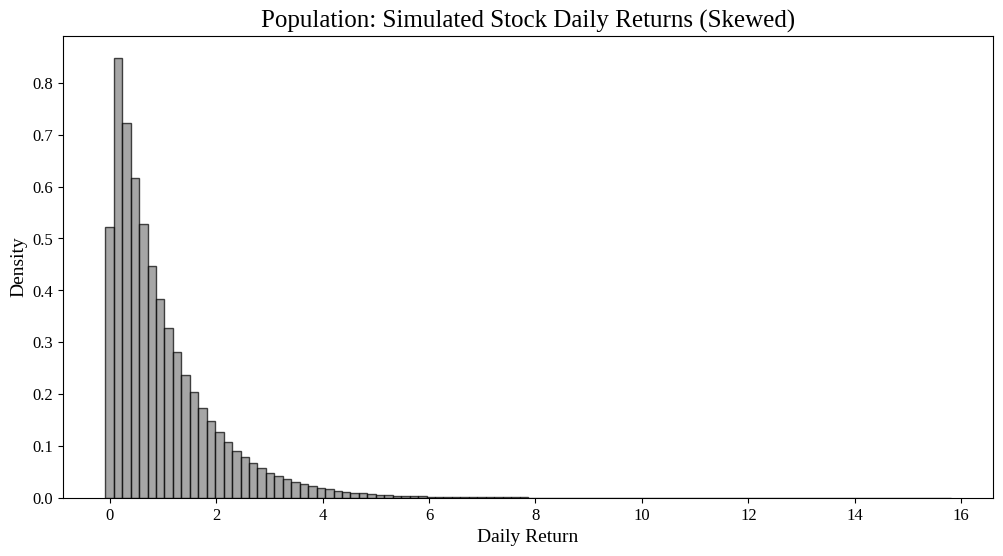

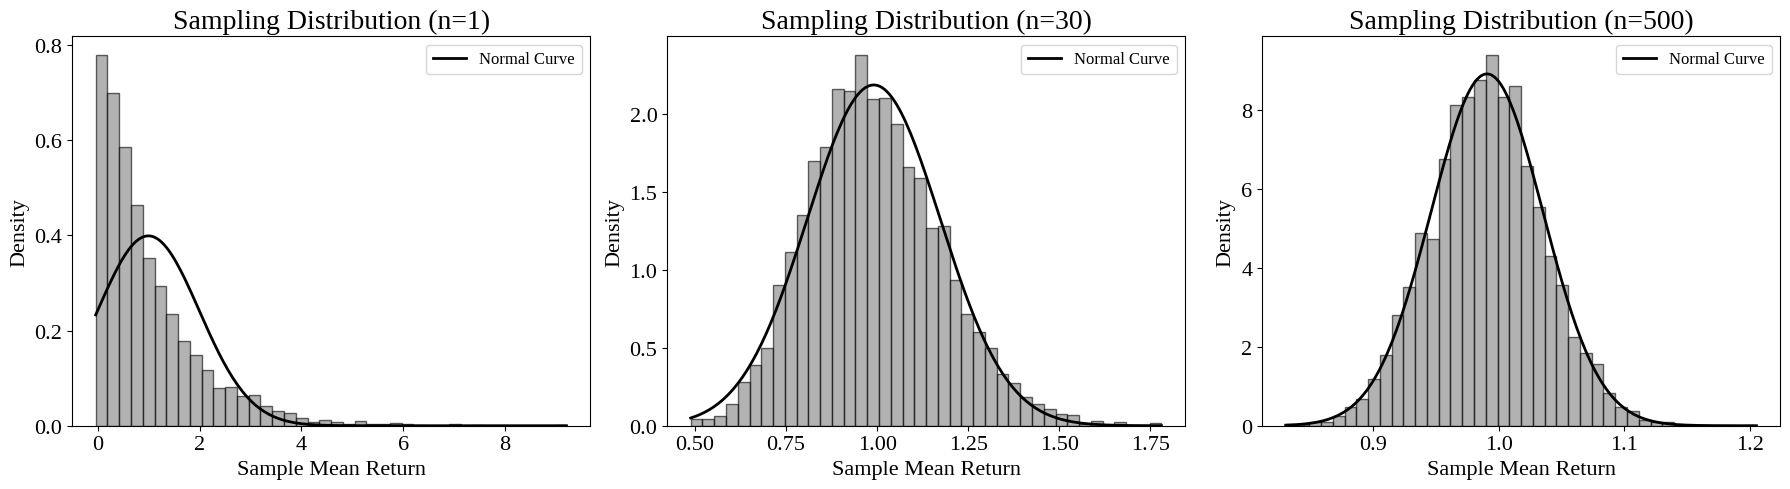

Population mean (approx): 0.990758626294031
Sample means (n=1) -> mean: 1.00620, std: 1.00660
Sample means (n=30) -> mean: 0.99284, std: 0.18146
Sample means (n=500) -> mean: 0.99040, std: 0.04461


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Set font globally
plt.rcParams['font.family'] = 'Liberation Serif'

# Seed for reproducibility
np.random.seed(42)

# ---- Step 1: Simulate stock daily returns (population) ----
population_size = 2000000
population_returns = np.random.normal(loc=0.001, scale=0.02, size=population_size)
population_returns += np.random.exponential(scale=1, size=population_size) - 0.01  # add skew

# ---- Step 2: Function to generate sample means ----
def get_sample_means(pop, n, sims=5000):
    return [np.mean(np.random.choice(pop, n, replace=True)) for _ in range(sims)]

# ---- Step 3: Generate sample means ----
sample_sizes = [1,30,500]
sample_means_dict = {n: get_sample_means(population_returns, n) for n in sample_sizes}

# ---- Step 4: Plot population distribution ----
plt.figure(figsize=(12,6))
plt.hist(population_returns, bins=100, color='grey', edgecolor='black', alpha=0.7, density=True)
plt.title("Population: Simulated Stock Daily Returns (Skewed)", fontsize=18)
plt.xlabel("Daily Return", fontsize=14)
plt.ylabel("Density", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

# ---- Step 5: Sampling distributions with normal curve overlay ----
pop_mean = np.mean(population_returns)
pop_std = np.std(population_returns)

fig, axes = plt.subplots(1, 3, figsize=(18,5))
for ax, n in zip(axes, sample_sizes):
    # Histogram of sample means
    data = sample_means_dict[n]
    ax.hist(data, bins=40, density=True, alpha=0.6, color='grey', edgecolor='black')

    # Overlay normal curve
    se = pop_std / np.sqrt(n)
    x = np.linspace(min(data), max(data), 200)
    ax.plot(x, norm.pdf(x, loc=pop_mean, scale=se), 'k-', lw=2, label="Normal Curve")

    # Bigger fonts for labels and title
    ax.set_title(f"Sampling Distribution (n={n})", fontsize=20)
    ax.set_xlabel("Sample Mean Return", fontsize=16)
    ax.set_ylabel("Density", fontsize=16)
    ax.tick_params(axis='both', labelsize=16)
    ax.legend(fontsize=12)

plt.tight_layout()
plt.show()

# ---- Step 6: Print stats ----
print("Population mean (approx):", pop_mean)
for n in sample_sizes:
    print(f"Sample means (n={n}) -> mean: {np.mean(sample_means_dict[n]):.5f}, std: {np.std(sample_means_dict[n]):.5f}")
